In [1]:
from pathlib import Path
import yaml, json

ROOT = Path.cwd()
DATA = ROOT / "data_yolo_dish"  # <- multi-dish dataset
assert (DATA/"train/images").exists(), "Missing train/images in data_yolo_dish"
assert (DATA/"val/images").exists() or (DATA/"valid/images").exists(), "Missing val/valid in data_yolo_dish"

val_key = "val" if (DATA/"val/images").exists() else "valid"
# names: keep your single "dish" or actual class list if you annotated per-class
# If your data_yolo_dish has class IDs aligned to class_names.json, do:
try:
    with open("class_names.json","r",encoding="utf-8") as f:
        NAMES = json.load(f)
except Exception:
    NAMES = ["dish"]  # fallback

yaml_dict = {
    "path": DATA.resolve().as_posix(),
    "train": "train/images",
    "val":   f"{val_key}/images",
    "names": NAMES
}
( DATA/"data.yaml" ).write_text(yaml.safe_dump(yaml_dict, sort_keys=False), encoding="utf-8")
print("Wrote", (DATA/"data.yaml").resolve())
print((DATA/"data.yaml").read_text())


Wrote C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\data.yaml
path: C:/Users/Jun Wei/Desktop/SIT/SIT Y2T1/Computer Vision and Deep Learning/Proj/food_classifier/data_yolo_dish
train: train/images
val: valid/images
names:
- Braised Crucian Carp
- Braised Pork
- Dry Pot Cauliflower
- Egg Drop Soup
- Fish Flavored Shredded Pork
- Fish Head Tofu Soup
- Fragrant Soy-sauced Eggplant
- Fried Milk Custard
- Glass Noodles with Minced Pork
- Hot and Sour Lotus Root Slices
- Kung Pao Chicken
- Scallion Oil Noodles
- Spicy Chongqing Hotpot
- Spicy Crab
- Spicy Tofu
- Steamed Pork with Rice Flour
- Stir-fried Pork Kidney
- Stir-fried Shredded Potatoes
- Tomato Scrambled Eggs
- Winter Melon Pork Rib Soup



In [2]:
from ultralytics import YOLO
import torch
from pathlib import Path

DATA_YAML = Path("data_yolo_dish/data.yaml")
assert DATA_YAML.exists()

# Start from a strong pretrain but small backbone (n or s).
# With 200 images, try yolov8n first; if underfitting, switch to yolov8s.
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATA_YAML),
    imgsz=768,                 # larger resolution helps small objects
    epochs=120,                # train longer but use early_stop
    batch=16,
    device=0 if torch.cuda.is_available() else "cpu",
    name="train_dishdet_multi",
    patience=30,               # early stop
    lr0=0.01, lrf=0.1,         # default LR schedule is fine; tweak if needed
    mosaic=1.0,                # keep mosaic; good for small datasets
    mixup=0.2,                 # mild mixup
    copy_paste=0.3,            # synthetic instances helps multi-object
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=0.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0,
    flipud=0.0, fliplr=0.5,
    erasing=0.2,               # random erasing helps robustness
    cos_lr=True,
    amp=True,
    cache="ram",               # faster on repeated epochs
)
best_weights = model.trainer.best
print("Best weights:", best_weights)


New https://pypi.org/project/ultralytics/8.3.226 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data_yolo_dish\data.yaml, epochs=120, time=None, patience=30, batch=16, imgsz=768, save=True, save_period=-1, cache=ram, device=0, workers=8, project=None, name=train_dishdet_multi, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=No

train: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\train\labels.cache... 170 images, 0 backgrounds, 0 corrupt: 100%|██████████| 170/170 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 127, len(boxes) = 1054. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


WARNING  cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


train: Caching images (0.2GB RAM): 100%|██████████| 170/170 [00:00<00:00, 211.80it/s]
val: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<?, ?it/s]

...

    116/120      3.32G     0.3774     0.5605     0.9288         55        768: 100%|██████████| 11/11 [00:02<00:00,  5.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  6.01it/s]

                   all         21        123      0.916      0.894      0.922      0.844
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 86, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



116 epochs completed in 0.105 hours.
Optimizer stripped from c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi\weights\last.pt, 5.7MB
Optimizer stripped from c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi\weights\best.pt, 5.7MB

Validating c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi\weights\best.pt...
Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 186 layers, 2,688,268 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.89it/s]


                   all         21        123      0.872      0.938      0.944      0.872
  Braised Crucian Carp         21        123      0.872      0.938      0.944      0.872
Speed: 0.4ms preprocess, 2.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi
Best weights: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi\weights\best.pt


In [3]:
from ultralytics import YOLO
from pathlib import Path

best_weights = Path("runs/detect/train_dishdet_multi/weights/best.pt")
yolo_best = YOLO(str(best_weights))

metrics = yolo_best.val(data="data_yolo_dish/data.yaml", imgsz=768)
print("mAP50:", metrics.results_dict.get("metrics/mAP50(B)"))
print("mAP50-95:", metrics.results_dict.get("metrics/mAP50-95(B)"))

Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 186 layers, 2,688,268 parameters, 0 gradients


val: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 8, len(boxes) = 123. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<00:00,  2.85s/it]


                   all         21        123      0.882      0.919      0.936      0.859
  Braised Crucian Carp         21        123      0.882      0.919      0.936      0.859
Speed: 3.7ms preprocess, 23.2ms inference, 0.0ms loss, 9.2ms postprocess per image
Results saved to c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\val2
mAP50: 0.9361459922770188
mAP50-95: 0.8588326436484724


In [7]:
from pathlib import Path
import os, json, numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont

import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO

BASE_DIR = Path.cwd()
CLASSMAP_JSON = BASE_DIR / "class_names.json"

# Robust register
try:
    from keras.saving import register_keras_serializable
except Exception:
    from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable(package="custom")
class RandomGrayscale(keras.layers.Layer):
    def __init__(self, p=0.7, **kw): super().__init__(**kw); self.p = p
    def call(self, x, training=False): return x

# Class names
with open(CLASSMAP_JSON, "r", encoding="utf-8") as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)

# Prefer SavedModel FOLDERS
MODEL_CONFIGS = {
    "fine_tuned": {
        "label": "EfficientNet-B3 (Gray-FT)",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3_grayft"),
    },
    "standard": {
        "label": "EfficientNet-B3 (Color)",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3")
    },
    "grayscale_robust": {
        "label": "EfficientNet-B3 Grayscale-Robust",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3_grayscale_robust")
    },
}

# TFSMLayer optional
try:
    from tensorflow.keras.layers import TFSMLayer
    HAVE_TFSM = True
except Exception:
    TFSMLayer = None
    HAVE_TFSM = False

class SavedModelWrapper(keras.Model):
    def __init__(self, sm):
        super().__init__()
        infer = sm.signatures['serving_default']
        self.input_key  = list(infer.structured_input_signature[1].keys())[0]
        self.output_key = list(infer.structured_outputs.keys())[0]
        self._infer = infer
    def call(self, x):
        out = self._infer(**{self.input_key: x})
        return out[self.output_key]

def load_food_model(model_key="standard"):
    p = MODEL_CONFIGS[model_key]["path"]
    if not os.path.exists(p):
        raise FileNotFoundError(f"Model path not found: {p}")
    # Try SavedModel via TFSMLayer
    if HAVE_TFSM:
        try:
            print(f"[clf] Loading SavedModel via TFSMLayer: {p}")
            return keras.Sequential([TFSMLayer(p, call_endpoint="serving_default")])
        except Exception as e:
            print("[clf] TFSMLayer failed:", e)
    # Fallback: tf.saved_model.load + wrapper
    try:
        print(f"[clf] Loading SavedModel via wrapper: {p}")
        sm = tf.saved_model.load(p)
        return SavedModelWrapper(sm)
    except Exception as e:
        # Last resort: a .keras file (if you saved one)
        print("[clf] SavedModel failed, trying .keras:", e)
        return keras.models.load_model(p, custom_objects={"RandomGrayscale": RandomGrayscale})

def load_detector():
    # Use the NEW multi-dish run name
    pt = BASE_DIR / "runs" / "detect" / "train_dishdet_multi" / "weights" / "best.pt"
    if not pt.exists():
        raise FileNotFoundError(f"Detector weights not found: {pt}")
    print("[det] Loading YOLO:", pt)
    return YOLO(str(pt))

clf_model = load_food_model("fine_tuned")
det_model = load_detector()

# Font
try:
    FONT = ImageFont.truetype(str((Path.home()/ "AppData/Roaming/Ultralytics/Arial.ttf")), 20)
except Exception:
    FONT = ImageFont.load_default()

print("Models ready:", MODEL_CONFIGS["standard"]["label"])

[clf] Loading SavedModel via TFSMLayer: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\models_tf\food_efficientnet_b3_grayft
[det] Loading YOLO: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi\weights\best.pt
Models ready: EfficientNet-B3 (Color)


In [9]:
# Classifier expects 342x342x3 raw RGB float32 (SavedModel does its own EfficientNet preprocessing)
CLF_SIZE = 342
DET_CONF = 0.35
DET_IOU  = 0.5

def resize_to_342(img_rgb):
    return cv2.resize(img_rgb, (CLF_SIZE, CLF_SIZE), interpolation=cv2.INTER_LINEAR)

def preprocess_for_clf(img_rgb):
    x = resize_to_342(img_rgb).astype(np.float32)  # NO /255.0
    return x[None, ...]  # NHWC

def crop_with_pad(img_rgb, xyxy, pad=0.10):
    H, W = img_rgb.shape[:2]
    x1, y1, x2, y2 = map(float, xyxy)
    cx, cy = (x1+x2)/2, (y1+y2)/2
    bw, bh = (x2-x1), (y2-y1)
    bw *= (1+pad); bh *= (1+pad)
    x1n, y1n = int(max(0, cx-bw/2)), int(max(0, cy-bh/2))
    x2n, y2n = int(min(W-1, cx+bw/2)), int(min(H-1, cy+bh/2))
    if y2n <= y1n or x2n <= x1n:
        return None, (x1n, y1n, x2n, y2n)
    return img_rgb[y1n:y2n, x1n:x2n].copy(), (x1n, y1n, x2n, y2n)

def draw_box(img_pil, box, label, color=(0, 140, 255)):
    draw = ImageDraw.Draw(img_pil)
    x1, y1, x2, y2 = [int(v) for v in box]
    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
    tw, th = draw.textbbox((0,0), label, font=FONT)[2:]
    draw.rectangle([x1, y1-th-6, x1+tw+8, y1], fill=color)
    draw.text((x1+4, y1-th-4), label, font=FONT, fill=(255,255,255))
    return img_pil

def _as_probs(out):
    # Handle dicts (TFSMLayer) or logits/probs arrays
    if isinstance(out, dict):
        return next(iter(out.values()))
    return out

def detect_and_classify(image_path, min_box_area=4000, keep_topk=20):
    bgr = cv2.imread(str(image_path))
    assert bgr is not None, f"Cannot read {image_path}"
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # A) detection
    res = det_model.predict(source=rgb, conf=DET_CONF, iou=DET_IOU, verbose=False)[0]
    boxes = res.boxes
    if boxes is None or len(boxes) == 0:
        return [], Image.fromarray(rgb)

    xyxy = boxes.xyxy.cpu().numpy()
    areas = (xyxy[:,2]-xyxy[:,0])*(xyxy[:,3]-xyxy[:,1])
    order = np.argsort(-areas)
    keep = [i for i in order if areas[i] >= min_box_area][:keep_topk]

    pil = Image.fromarray(rgb)
    detections = []

    # B) classification per crop
    for i in keep:
        crop, box = crop_with_pad(rgb, xyxy[i], pad=0.10)
        if crop is None:
            continue
        x = preprocess_for_clf(crop)
        out = clf_model.predict(x, verbose=0)
        probs = np.array(_as_probs(out))
        if probs.ndim == 1:         # rare case
            probs = probs[None, ...]
        if probs.shape[-1] != len(CLASS_NAMES):
            probs = tf.nn.softmax(probs, axis=-1).numpy()
        p = probs[0]
        cls_id = int(np.argmax(p))
        score  = float(p[cls_id])
        name   = CLASS_NAMES[cls_id]

        label = f"{name} {score:.2f}"
        pil = draw_box(pil, box, label)

        detections.append({
            "box_xyxy": tuple(map(int, box)),
            "cls_id": cls_id,
            "cls_name": name,
            "score": score
        })

    return detections, pil


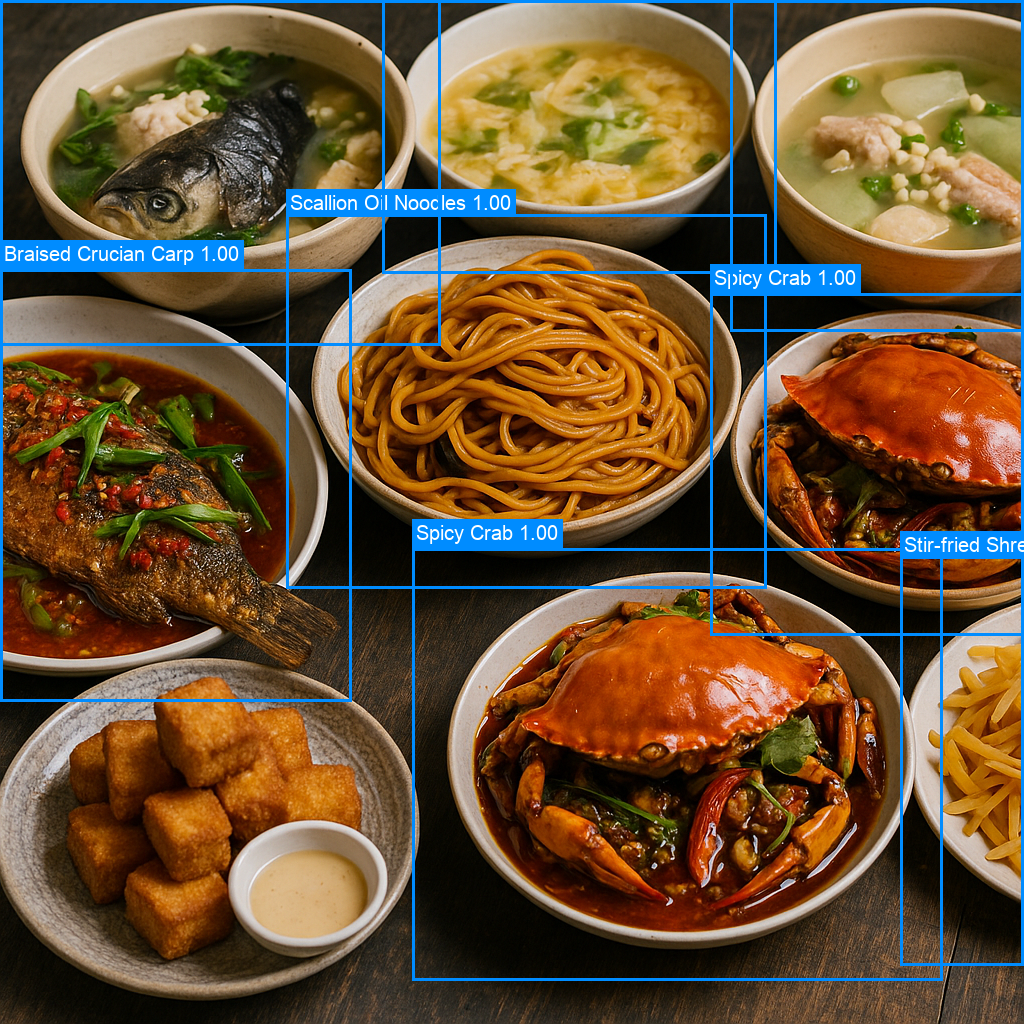

8 detections
{'box_xyxy': (412, 548, 942, 980), 'cls_id': 13, 'cls_name': 'Spicy Crab', 'score': 0.9997887015342712}
{'box_xyxy': (286, 214, 766, 588), 'cls_id': 11, 'cls_name': 'Scallion Oil Noodles', 'score': 0.9997283816337585}
{'box_xyxy': (0, 0, 440, 345), 'cls_id': 5, 'cls_name': 'Fish Head Tofu Soup', 'score': 0.7141214609146118}
{'box_xyxy': (0, 269, 351, 701), 'cls_id': 0, 'cls_name': 'Braised Crucian Carp', 'score': 0.999115526676178}
{'box_xyxy': (382, 0, 776, 273), 'cls_id': 3, 'cls_name': 'Egg Drop Soup', 'score': 0.9693289995193481}
{'box_xyxy': (710, 293, 1023, 635), 'cls_id': 13, 'cls_name': 'Spicy Crab', 'score': 0.9996922016143799}
{'box_xyxy': (730, 0, 1023, 331), 'cls_id': 19, 'cls_name': 'Winter Melon Pork Rib Soup', 'score': 0.9967593550682068}
{'box_xyxy': (900, 556, 1023, 965), 'cls_id': 17, 'cls_name': 'Stir-fried Shredded Potatoes', 'score': 0.9893372058868408}


In [ ]:
# Single image
TEST_IMAGE = "data_clean/prediction/detection/Image2.png"
dets, vis = detect_and_classify(TEST_IMAGE, min_box_area=3000)
display(vis)
print(f"{len(dets)} detections")
for d in dets:
    print(d)
